In [ ]:
import sys
import subprocess

packages = [
    "torch",
    "torchvision",
    "medmnist",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "tqdm"
]

for p in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])


In [ ]:

# 1. IMPORTACIONES

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as T
import torchvision.models as models
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, accuracy_score
import medmnist
from medmnist import INFO

In [ ]:

# 2. INFORMACIÓN DEL DATASET

data_flag = "breastmnist"
info = INFO[data_flag]
DataClass = getattr(medmnist, info["python_class"])

print("Task:", info["task"])
print("Number of classes:", len(info["label"]))
print("Labels:", info["label"])

Task: binary-class
Number of classes: 2
Labels: {'0': 'malignant', '1': 'normal, benign'}


In [ ]:

# 3. TRANSFORMACIONES

transform = T.Compose([
    T.ToTensor(),
    T.Resize((224, 224)),  # Necesario para ResNet
    T.Normalize(mean=[0.5], std=[0.5])
])

In [ ]:

# 4. CARGA DEL DATASET

train_dataset = DataClass(split="train", transform=transform, download=True)
val_dataset   = DataClass(split="val", transform=transform, download=True)
test_dataset  = DataClass(split="test", transform=transform, download=True)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

100%|██████████| 560k/560k [00:00<00:00, 668kB/s]


Train: 546
Validation: 78
Test: 156


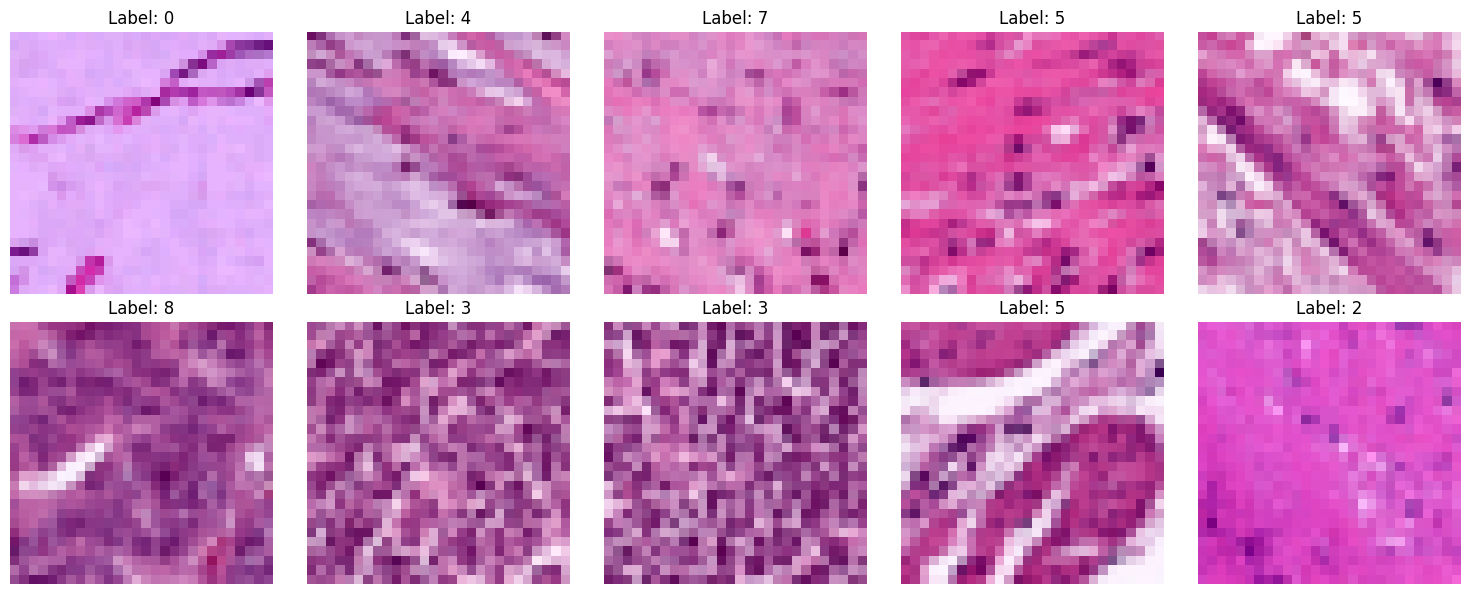

In [9]:

import matplotlib.pyplot as plt

num_images = 10

cols = 5
rows = num_images // cols + (num_images % cols != 0)

fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))

axes = axes.flatten()

for i in range(num_images):
    image, label = train_dataset[i]

    # CHW → HWC
    image = image.permute(1, 2, 0).numpy()

    # normalización para que se vea claro
    image = (image - image.min()) / (image.max() - image.min() + 1e-8)

    # si es grayscale
    if image.shape[-1] == 1:
        image = image.squeeze(-1)
        axes[i].imshow(image, cmap="gray", vmin=0, vmax=1)
    else:
        axes[i].imshow(image)

    label_value = label.item() if hasattr(label, "item") else label
    axes[i].set_title(f"Label: {label_value}")
    axes[i].axis("off")

# ocultar espacios vacíos si no llena la grilla
for j in range(num_images, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


In [ ]:

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:

# 8. MODELO TRANSFER LEARNING (RESNET18)

model = models.resnet18(pretrained=True)

# Congelar todas las capas
for param in model.parameters():
    param.requires_grad = False

# Reemplazar última capa
model.fc = nn.Linear(model.fc.in_features, 1)

model = model.to(device)

print(model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 112MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:

# 9. FUNCIÓN DE PÉRDIDA Y OPTIMIZADOR

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

100%|██████████| 18/18 [00:02<00:00,  6.35it/s]


Epoch 01 | train_loss=0.6479 | train_acc=0.7253 | val_loss=0.5761 | val_acc=0.7308 | val_auc=0.6475


100%|██████████| 18/18 [00:00<00:00, 19.64it/s]


Epoch 02 | train_loss=0.5475 | train_acc=0.7308 | val_loss=0.5682 | val_acc=0.7308 | val_auc=0.6291


100%|██████████| 18/18 [00:00<00:00, 19.35it/s]


...

Epoch 18 | train_loss=0.4074 | train_acc=0.8004 | val_loss=0.4066 | val_acc=0.8462 | val_auc=0.8513


100%|██████████| 18/18 [00:01<00:00, 17.74it/s]


Epoch 19 | train_loss=0.3885 | train_acc=0.8571 | val_loss=0.4130 | val_acc=0.8077 | val_auc=0.8722


100%|██████████| 18/18 [00:00<00:00, 19.08it/s]


Epoch 20 | train_loss=0.3859 | train_acc=0.8260 | val_loss=0.3947 | val_acc=0.8333 | val_auc=0.8638


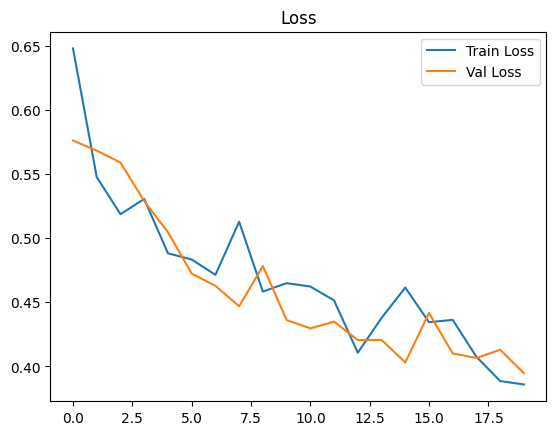

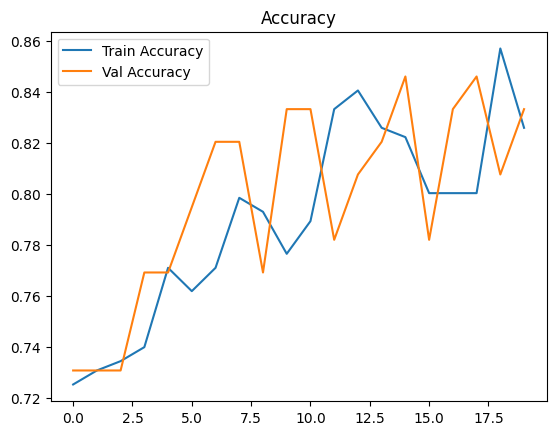

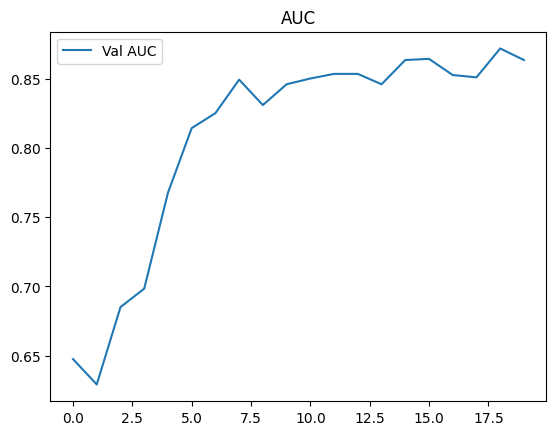

In [ ]:

# 10. ENTRENAMIENTO


import torch
from tqdm import tqdm
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

num_epochs = 20

train_losses = []
val_losses = []
train_accs = []
val_accs = []
val_aucs = []

for epoch in range(num_epochs):

    # ----------------- TRAIN -----------------
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader):

        images = images.repeat(1, 3, 1, 1).to(device)

        # 🔥 IMPORTANTE: mantener shape [B,1]
        labels = labels.float().to(device)

        optimizer.zero_grad()

        outputs = model(images)  # ❌ SIN squeeze()

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5)

        correct += (preds == labels.bool()).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # validacion
    val_running_loss = 0
    correct = 0
    total = 0

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.repeat(1, 3, 1, 1).to(device)
            labels = labels.float().to(device)

            outputs = model(images)  # ❌ SIN squeeze()

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5)

            correct += (preds == labels.bool()).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    val_loss = val_running_loss / len(val_loader)
    val_acc = correct / total
    val_auc = roc_auc_score(all_labels, all_probs)

    val_losses.append(val_loss)
    val_accs.append(val_acc)
    val_aucs.append(val_auc)

    print(f"Epoch {epoch+1:02d} | "
          f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


# 11. GRÁFICAS


plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Val Accuracy")
plt.title("Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(val_aucs, label="Val AUC")
plt.title("AUC")
plt.legend()
plt.show()

In [ ]:

# 11. EVALUACIÓN FINAL EN TEST

model.eval()
correct = 0
total = 0
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.repeat(1,3,1,1)
        images = images.to(device)
        labels = labels.float().to(device)

        outputs = model(images).squeeze()
        probs = torch.sigmoid(outputs)
        preds = probs > 0.5

        correct += (preds == labels.bool()).sum().item()
        total += labels.size(0)

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

test_acc = correct / total
test_auc = roc_auc_score(all_labels, all_probs)

print("\nTest Accuracy:", test_acc)
print("Test AUC:", test_auc)


Test Accuracy: 19.846153846153847
Test AUC: 0.8109857978279031


In [5]:

# 13. GUARDAR MODELO

torch.save(model.state_dict(), "breastmnist_resnet18.pth")


Device: cuda


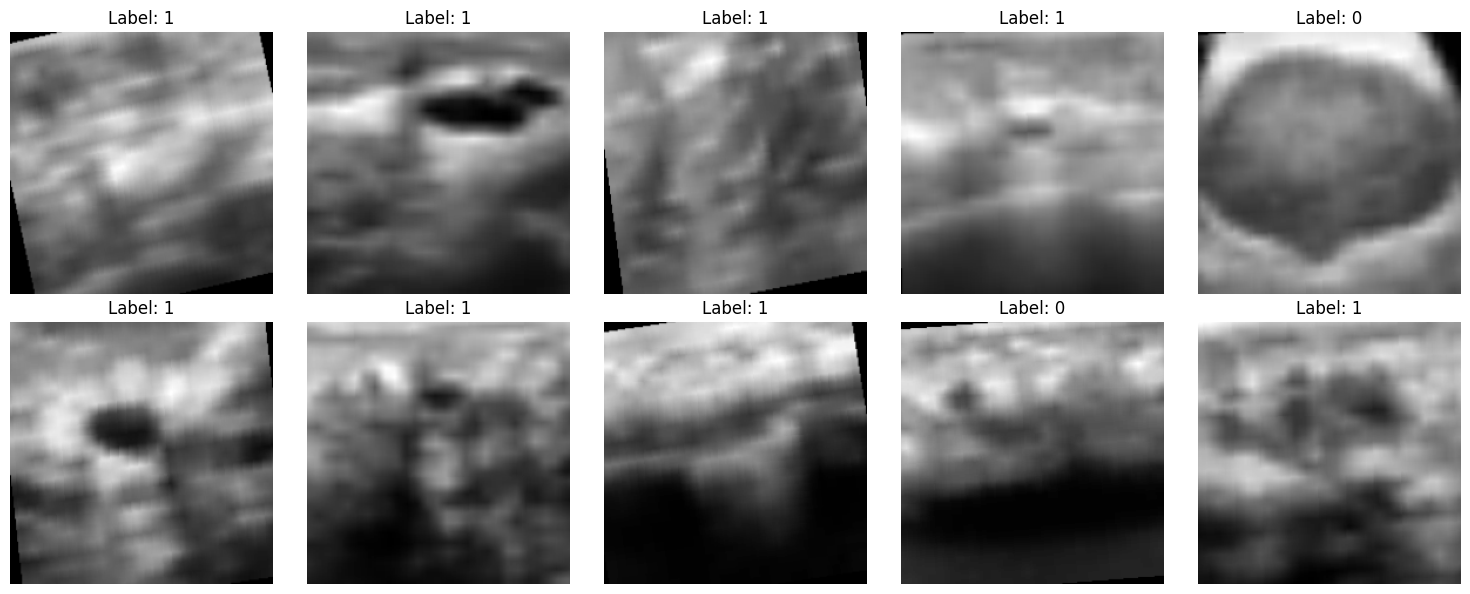

100%|██████████| 18/18 [00:02<00:00,  8.76it/s]


Epoch 1 | AUC: 0.6349


100%|██████████| 18/18 [00:01<00:00,  9.29it/s]


Epoch 2 | AUC: 0.6608


100%|██████████| 18/18 [00:02<00:00,  8.44it/s]


...

Epoch 18 | AUC: 0.8053


100%|██████████| 18/18 [00:01<00:00,  9.16it/s]


Epoch 19 | AUC: 0.8120


100%|██████████| 18/18 [00:02<00:00,  7.83it/s]


Epoch 20 | AUC: 0.8262

TEST AUC: 0.810985797827903
Best threshold: 0.5409090909090909
Best Test Accuracy: 0.7948717948717948


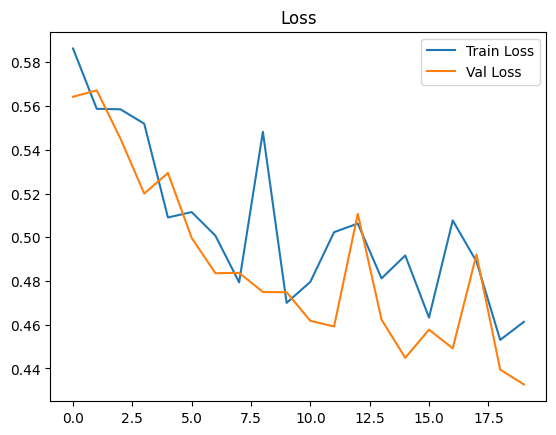

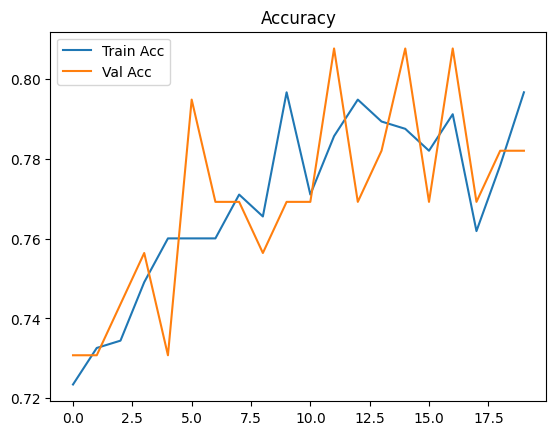

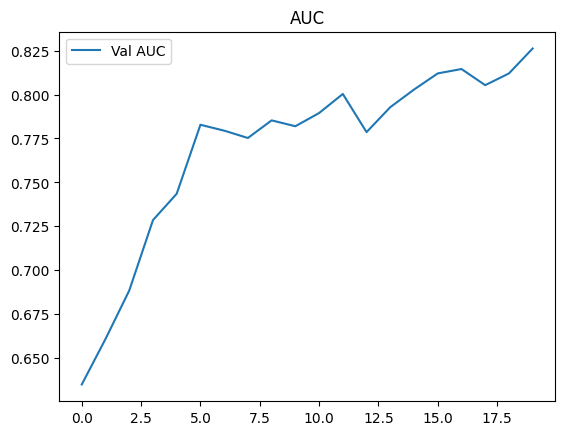

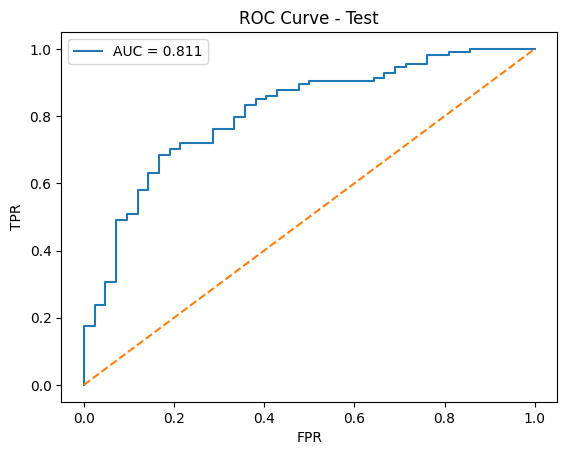

In [12]:

# 0. LIBRERÍAS

import sys
import subprocess

packages = [
    "torch",
    "torchvision",
    "medmnist",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "tqdm"
]

for p in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])




import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as T
import torchvision.models as models
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve
import medmnist
from medmnist import INFO

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# 3. TRANSFORMS (DATA AUGMENTATION + FIX CANALES)

transform_train = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.RandomResizedCrop(224, scale=(0.8, 1.0)),
    T.Grayscale(num_output_channels=3),
    T.ToTensor(),
    T.Normalize([0.485]*3, [0.229]*3)
])

transform_test = T.Compose([
    T.Resize((224, 224)),
    T.Grayscale(num_output_channels=3),
    T.ToTensor(),
    T.Normalize([0.485]*3, [0.229]*3)
])


# 4. DATASET

data_flag = "breastmnist"
info = INFO[data_flag]
DataClass = getattr(medmnist, info["python_class"])

train_dataset = DataClass(split="train", transform=transform_train, download=True)
val_dataset   = DataClass(split="val", transform=transform_test, download=True)
test_dataset  = DataClass(split="test", transform=transform_test, download=True)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)


# 5. VISUALIZAR 10 IMÁGENES CON LABELS

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(10):
    img, label = train_dataset[i]

    img = img.permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    axes[i].imshow(img)
    axes[i].set_title(f"Label: {label.item()}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()


# 6. MODEL
model = models.resnet18(weights="IMAGENET1K_V1")

for p in model.parameters():
    p.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, 1)
model = model.to(device)


# 7. LOSS + OPTIMIZER

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)


# 8. ENTRENAMIENTO

epochs = 20

train_losses, val_losses = [], []
train_accs, val_accs, val_aucs = [], [], []

for epoch in range(epochs):

    model.train()

    loss_sum = 0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.float().to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        loss_sum += loss.item()

        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5)

        correct += (preds == labels.bool()).sum().item()
        total += labels.size(0)

    train_losses.append(loss_sum / len(train_loader))
    train_accs.append(correct / total)


    model.eval()

    val_loss_sum = 0
    correct = 0
    total = 0

    y_true, y_prob = [], []

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.float().to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss_sum += loss.item()

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5)

            correct += (preds == labels.bool()).sum().item()
            total += labels.size(0)

            y_true.extend(labels.cpu().numpy())
            y_prob.extend(probs.cpu().numpy())

    val_losses.append(val_loss_sum / len(val_loader))
    val_accs.append(correct / total)
    val_aucs.append(roc_auc_score(y_true, y_prob))

    print(f"Epoch {epoch+1} | AUC: {val_aucs[-1]:.4f}")


# 9. TEST

model.eval()

y_test, p_test = [], []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.float().to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs)

        y_test.extend(labels.cpu().numpy())
        p_test.extend(probs.cpu().numpy())

y_test = np.array(y_test)
p_test = np.array(p_test)

test_auc = roc_auc_score(y_test, p_test)
print("\nTEST AUC:", test_auc)


best_acc = 0
best_t = 0.5

for t in np.linspace(0.05, 0.95, 100):
    preds = (p_test > t)
    acc = accuracy_score(y_test, preds)

    if acc > best_acc:
        best_acc = acc
        best_t = t

print("Best threshold:", best_t)
print("Best Test Accuracy:", best_acc)


# 11. GRÁFICAS ENTRENAMIENTO

plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss")
plt.show()

plt.figure()
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend()
plt.title("Accuracy")
plt.show()

plt.figure()
plt.plot(val_aucs, label="Val AUC")
plt.legend()
plt.title("AUC")
plt.show()


fpr, tpr, _ = roc_curve(y_test, p_test)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {test_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve - Test")
plt.legend()
plt.show()